# Planar Data Classification: KAN vs Neural Network

This notebook follows the **exact same structure** as `Planar_data_classification_with_one_hidden_layer.ipynb`, but replaces the standard Neural Network with a **KAN (Kolmogorov-Arnold Network)** built from scratch.

By the end you'll be able to:
- Understand **what KAN is** and how it differs from a standard NN
- Implement a KAN from scratch using only NumPy
- Run it on the same flower dataset and compare results

---

## 🧠 NN vs KAN — The Core Difference

### Standard Neural Network (what you built)
```
z = W · x + b        ← linear combination with learnable weights W
a = tanh(z)          ← FIXED activation function on NODES
```
- **Learnable**: weights W and biases b on **edges**
- **Fixed**: activation function (tanh, ReLU, sigmoid) on **nodes**
- Learns: **how much** to scale/combine each feature

### KAN (Kolmogorov-Arnold Network)
```
output[j] = Σᵢ φᵢⱼ(xᵢ)    ← sum of LEARNED functions on EDGES
```
- **Learnable**: the activation function φ itself (B-spline curves) on **edges**
- **Fixed**: just a sum on **nodes**
- Learns: **how to transform** each feature, not just how much to weight it

### Side-by-side comparison

| | Neural Network | KAN |
|---|---|---|
| Weights on | edges (W, b) | edges (spline coefficients) |
| Activations on | **nodes** — fixed (tanh) | **edges** — learned (B-spline) |
| Learns | scale/combine features | transform shape of each feature |
| Interpretable | ✗ W is opaque | ✓ you can plot each φ curve |
| Good for | large vision/text tasks | discovering mathematical structure |

**KANs are based on the Kolmogorov-Arnold theorem (1957)**: any continuous function can be written as sums of continuous single-variable functions. KANs make this trainable.

> Reference: Liu et al., "KAN: Kolmogorov-Arnold Networks", arXiv:2404.19756 (2024)

## Table of Contents
- [1 - Packages](#1)
- [2 - Load the Dataset](#2)
- [3 - Simple Logistic Regression (baseline)](#3)
- [4 - Standard NN (your original model)](#4)
- [5 - KAN Model](#5)
  - [5.1 - What are B-splines?](#5-1)
  - [5.2 - Defining the KAN structure](#5-2)
  - [5.3 - Forward Propagation](#5-3)
  - [5.4 - Compute the Cost](#5-4)
  - [5.5 - Backward Propagation](#5-5)
  - [5.6 - Training: the Loop](#5-6)
- [6 - Compare Results: NN vs KAN](#6)
- [7 - Visualize the Learned Functions (KAN's superpower)](#7)

<a name='1'></a>
## 1 - Packages

Same as your original assignment — only NumPy, matplotlib, sklearn. No special KAN library needed.

In [1]:
import numpy as np
import copy
import matplotlib.pyplot as plt
import sklearn
import sklearn.datasets
import sklearn.linear_model

%matplotlib inline

# ── Utility functions (normally from planar_utils) ──────────────────────────
# Re-implemented here so the notebook is fully self-contained.

def sigmoid(x):
    """Sigmoid activation — same as in your assignment."""
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def load_planar_dataset():
    """Generate the flower-shaped dataset from your assignment."""
    np.random.seed(1)
    m = 400
    N = int(m / 2)
    X = np.zeros((m, 2))
    Y = np.zeros((m, 1), dtype='uint8')
    a = 4
    for j in range(2):
        ix = range(N * j, N * (j + 1))
        t = np.linspace(j * 3.12, (j + 1) * 3.12, N) + np.random.randn(N) * 0.2
        r = a * np.sin(4 * t) + np.random.randn(N) * 0.2
        X[ix] = np.c_[r * np.sin(t), r * np.cos(t)]
        Y[ix] = j
    return X.T, Y.T  # shapes: (2, 400), (1, 400)

def plot_decision_boundary(model, X, Y):
    """Plot decision boundary — same as in your assignment."""
    x_min, x_max = X[0, :].min() - 1, X[0, :].max() + 1
    y_min, y_max = X[1, :].min() - 1, X[1, :].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    Z = model(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
    plt.scatter(X[0, :], X[1, :], c=Y.ravel(), s=40, cmap=plt.cm.Spectral)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

print("✓ Packages loaded!")

✓ Packages loaded!


<a name='2'></a>
## 2 - Load the Dataset

Same flower-shaped dataset as your original assignment — 400 points, red (y=0) and blue (y=1).

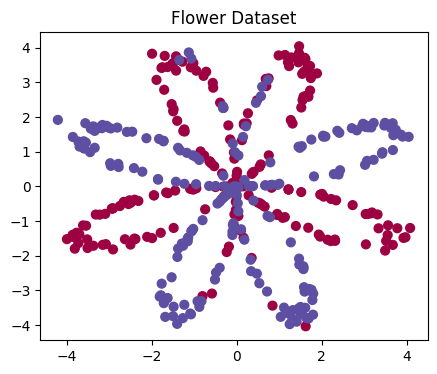

Shape of X: (2, 400)
Shape of Y: (1, 400)
Training examples m = 400


In [2]:
X, Y = load_planar_dataset()

plt.figure(figsize=(5, 4))
plt.scatter(X[0, :], X[1, :], c=Y.ravel(), s=40, cmap=plt.cm.Spectral)
plt.title("Flower Dataset")
plt.show()

print('Shape of X:', X.shape)   # (2, 400) — 2 features, 400 examples
print('Shape of Y:', Y.shape)   # (1, 400) — 1 label per example
print('Training examples m =', X.shape[1])

<a name='3'></a>
## 3 - Simple Logistic Regression (baseline)

Same as your original — barely works (~47%) because the flower isn't linearly separable.

/Users/lensa/Term_3/Research/papers/Quantum Paper/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/lensa/Term_3/Research/papers/Quantum Paper/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for mo

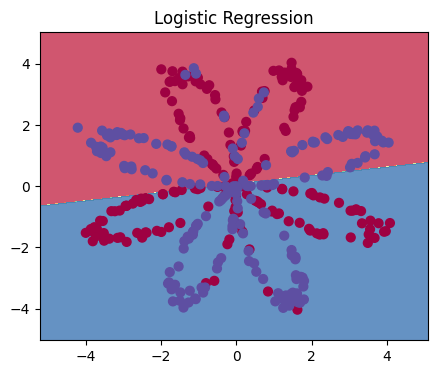

Accuracy of logistic regression: 47%
→ Bad! The dataset is not linearly separable.


/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_3567/2917140696.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  LR_acc = float((np.dot(Y, LR_predictions) + np.dot(1 - Y, 1 - LR_predictions)) / float(Y.size) * 100)


In [3]:
clf = sklearn.linear_model.LogisticRegressionCV()
clf.fit(X.T, Y.T.ravel())

plt.figure(figsize=(5, 4))
plot_decision_boundary(lambda x: clf.predict(x), X, Y)
plt.title("Logistic Regression")
plt.show()

LR_predictions = clf.predict(X.T)
LR_acc = float((np.dot(Y, LR_predictions) + np.dot(1 - Y, 1 - LR_predictions)) / float(Y.size) * 100)
print(f'Accuracy of logistic regression: {LR_acc:.0f}%')
print("→ Bad! The dataset is not linearly separable.")

<a name='4'></a>
## 4 - Standard NN (your original model, for comparison)

This is exactly what you built. We run it here to compare with KAN.

**NN forward propagation:**
$$Z^{[1]} = W^{[1]}X + b^{[1]}$$
$$A^{[1]} = \tanh(Z^{[1]})$$
$$Z^{[2]} = W^{[2]}A^{[1]} + b^{[2]}$$
$$\hat{Y} = A^{[2]} = \sigma(Z^{[2]})$$

In [4]:
# ── Your original NN (same functions as your assignment) ────────────────────

def nn_initialize_parameters(n_x, n_h, n_y):
    np.random.seed(2)
    return {
        "W1": np.random.randn(n_h, n_x) * 0.01,
        "b1": np.zeros((n_h, 1)),
        "W2": np.random.randn(n_y, n_h) * 0.01,
        "b2": np.zeros((n_y, 1))
    }

def nn_forward_propagation(X, params):
    W1, b1, W2, b2 = params["W1"], params["b1"], params["W2"], params["b2"]
    Z1 = W1 @ X + b1
    A1 = np.tanh(Z1)           # fixed tanh on nodes
    Z2 = W2 @ A1 + b2
    A2 = sigmoid(Z2)
    return A2, {"A1": A1, "A2": A2}

def nn_compute_cost(A2, Y):
    m = Y.shape[1]
    cost = -np.sum(np.log(A2 + 1e-8) * Y + np.log(1 - A2 + 1e-8) * (1 - Y)) / m
    return float(np.squeeze(cost))

def nn_backward_propagation(params, cache, X, Y):
    m = X.shape[1]
    A1, A2 = cache["A1"], cache["A2"]
    W2 = params["W2"]
    dZ2 = A2 - Y
    dW2 = (1/m) * dZ2 @ A1.T
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)
    dZ1 = W2.T @ dZ2 * (1 - A1**2)   # tanh derivative
    dW1 = (1/m) * dZ1 @ X.T
    db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)
    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

def nn_update_parameters(params, grads, lr=1.2):
    return {
        "W1": copy.deepcopy(params["W1"]) - lr * grads["dW1"],
        "b1": params["b1"] - lr * grads["db1"],
        "W2": copy.deepcopy(params["W2"]) - lr * grads["dW2"],
        "b2": params["b2"] - lr * grads["db2"]
    }

def nn_model(X, Y, n_h=4, num_iterations=10000, print_cost=False):
    np.random.seed(3)
    params = nn_initialize_parameters(X.shape[0], n_h, Y.shape[0])
    costs = []
    for i in range(num_iterations):
        A2, cache = nn_forward_propagation(X, params)
        cost = nn_compute_cost(A2, Y)
        grads = nn_backward_propagation(params, cache, X, Y)
        params = nn_update_parameters(params, grads)
        costs.append(cost)
        if print_cost and i % 1000 == 0:
            print(f"  Cost after iteration {i}: {cost:.6f}")
    return params, costs

def nn_predict(params, X):
    A2, _ = nn_forward_propagation(X, params)
    return (A2 > 0.5).astype(int)

# ── Train NN ────────────────────────────────────────────────────────────────
print("Training NN...")
nn_params, nn_costs = nn_model(X, Y, n_h=4, num_iterations=10000, print_cost=True)

nn_preds = nn_predict(nn_params, X)
nn_acc = float((np.dot(Y, nn_preds.T) + np.dot(1 - Y, 1 - nn_preds.T)) / float(Y.size) * 100)
print(f"\nNN Accuracy: {nn_acc:.0f}%")

Training NN...
  Cost after iteration 0: 0.693048
  Cost after iteration 1000: 0.288083
  Cost after iteration 2000: 0.254385


/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_3567/869654965.py:16: RuntimeWarning: divide by zero encountered in matmul
  Z2 = W2 @ A1 + b2
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_3567/869654965.py:16: RuntimeWarning: overflow encountered in matmul
  Z2 = W2 @ A1 + b2
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_3567/869654965.py:16: RuntimeWarning: invalid value encountered in matmul
  Z2 = W2 @ A1 + b2


  Cost after iteration 3000: 0.233864
  Cost after iteration 4000: 0.226792
  Cost after iteration 5000: 0.222644
  Cost after iteration 6000: 0.219731
  Cost after iteration 7000: 0.217504
  Cost after iteration 8000: 0.219397
  Cost after iteration 9000: 0.218542

NN Accuracy: 91%


/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_3567/869654965.py:68: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  nn_acc = float((np.dot(Y, nn_preds.T) + np.dot(1 - Y, 1 - nn_preds.T)) / float(Y.size) * 100)


<a name='5'></a>
## 5 - KAN Model

Now we build the KAN. Same structure as Section 4 — we'll mirror every step.

<a name='5-1'></a>
### 5.1 - What are B-splines? (The heart of KAN)

In your NN, each node applied a **fixed** function: `tanh(z)`.

In a KAN, **every connection** between two neurons has its **own learnable function** — a **B-spline**. You can think of a B-spline as a flexible rubber curve that can bend into any shape:

$$\varphi(x) = \sum_k c_k \cdot B_k(x)$$

- $B_k(x)$ = fixed bump functions that are each non-zero in a small region
- $c_k$ = **learned coefficients** (these are what gradient descent updates)
- Together they can approximate any smooth function

**Why is this more powerful than tanh?**  
- tanh is one fixed S-shape — it can't change
- A B-spline can learn to be a sine wave, a step, a parabola, or anything else
- KAN has more expressive power per parameter for structured/mathematical data

/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_3567/1054452007.py:45: RuntimeWarning: divide by zero encountered in matmul
  phi = B_demo @ c
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_3567/1054452007.py:45: RuntimeWarning: overflow encountered in matmul
  phi = B_demo @ c
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_3567/1054452007.py:45: RuntimeWarning: invalid value encountered in matmul
  phi = B_demo @ c


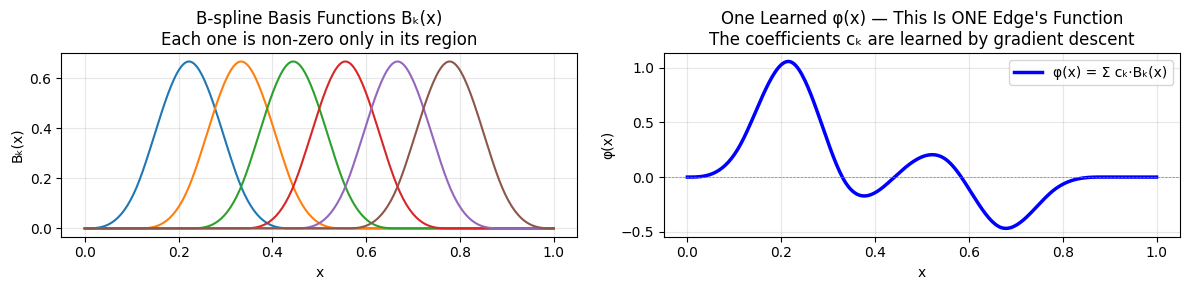

KEY INSIGHT:
  NN: every node applies the same tanh shape — fixed forever
  KAN: every EDGE learns its own φ shape (like the blue curve above)


In [5]:
# ── Visualize B-spline basis functions ─────────────────────────────────────
# This shows what the KAN's building blocks look like.

def demo_bspline_basis(n_basis=6, degree=3):
    """Show what B-spline basis functions look like."""
    x = np.linspace(0, 1, 300)
    n_k = n_basis + degree + 1
    knots = np.linspace(0, 1, n_k)

    # Degree-0 indicator functions
    B = np.zeros((len(x), n_k - 1))
    for k in range(n_k - 1):
        B[:, k] = (x >= knots[k]) & (x < knots[k+1])
    B[x == knots[-1], -1] = 1.0
    B = B.astype(float)
    # Recurse to degree
    for d in range(1, degree + 1):
        n_new = n_k - 1 - d
        B_new = np.zeros((len(x), n_new))
        for k in range(n_new):
            d1 = knots[k+d] - knots[k]
            d2 = knots[k+d+1] - knots[k+1]
            t1 = ((x - knots[k]) / d1 * B[:, k]) if d1 > 1e-10 else 0
            t2 = ((knots[k+d+1] - x) / d2 * B[:, k+1]) if d2 > 1e-10 else 0
            B_new[:, k] = t1 + t2
        B = B_new
    return x, B

x_demo, B_demo = demo_bspline_basis()

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Left: basis functions
for i in range(B_demo.shape[1]):
    axes[0].plot(x_demo, B_demo[:, i])
axes[0].set_title("B-spline Basis Functions Bₖ(x)\n"
                  "Each one is non-zero only in its region")
axes[0].set_xlabel("x")
axes[0].set_ylabel("Bₖ(x)")
axes[0].grid(True, alpha=0.3)

# Right: a learned combination
np.random.seed(7)
c = np.random.randn(B_demo.shape[1])
phi = B_demo @ c
axes[1].plot(x_demo, phi, 'b-', lw=2.5, label='φ(x) = Σ cₖ·Bₖ(x)')
axes[1].axhline(0, color='gray', lw=0.5, linestyle='--')
axes[1].set_title("One Learned φ(x) — This Is ONE Edge's Function\n"
                  "The coefficients cₖ are learned by gradient descent")
axes[1].set_xlabel("x")
axes[1].set_ylabel("φ(x)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("KEY INSIGHT:")
print("  NN: every node applies the same tanh shape — fixed forever")
print("  KAN: every EDGE learns its own φ shape (like the blue curve above)")

<a name='5-2'></a>
### 5.2 - Defining the KAN structure

Same architecture shape as your NN:  
`[2 inputs] → [4 hidden] → [1 output]`

But instead of W and b matrices, each layer stores **spline coefficients**:
- Layer 1: 2 × 4 = **8 spline functions**, one per edge
- Layer 2: 4 × 1 = **4 spline functions**, one per edge

Each spline function has `G + degree` coefficients (we use G=5, degree=3 → 8 coefficients each).

In [6]:
# ══════════════════════════════════════════════════════════════════
#  KAN CORE: B-spline basis computation with exact derivatives
# ══════════════════════════════════════════════════════════════════

def bspline_basis_and_deriv(x, knots, degree):
    """
    Compute B-spline basis functions AND their derivatives.

    We need the derivative for backpropagation (to pass gradients
    back to the input x, so the previous layer can learn too).

    x     : shape (n_in, m)      — input values for all features and examples
    knots : the spline knot grid
    degree: polynomial degree (3 = cubic, smooth curve)

    Returns:
    B  : shape (n_in, m, n_basis) — basis values
    dB : shape (n_in, m, n_basis) — basis derivatives w.r.t. x
    """
    n_in, m = x.shape
    d = degree
    n_k = len(knots)

    # Clamp x to valid range of knots
    x_c = np.clip(x, knots[d], knots[-(d+1)])

    # Build all intermediate bases B^0, B^1, ..., B^d  (needed for derivative)
    Bs = []

    # B^0: indicator functions — 1 if x falls in interval [t_k, t_{k+1}), else 0
    B = np.zeros((n_in, m, n_k - 1))
    for k in range(n_k - 1):
        B[:, :, k] = (x_c >= knots[k]) & (x_c < knots[k+1])
    B[:, :, -1] += (x_c == knots[-1])   # handle right endpoint
    B = B.astype(float)
    Bs.append(B)

    # Cox-de Boor recursion: build B^1, B^2, ..., B^d
    for deg in range(1, d + 1):
        n_new = n_k - 1 - deg
        B_new = np.zeros((n_in, m, n_new))
        for k in range(n_new):
            d1 = knots[k + deg] - knots[k]
            d2 = knots[k + deg + 1] - knots[k + 1]
            t1 = ((x_c - knots[k]) / d1 * Bs[-1][:, :, k])       if d1 > 1e-10 else 0
            t2 = ((knots[k+deg+1] - x_c) / d2 * Bs[-1][:, :, k+1]) if d2 > 1e-10 else 0
            B_new[:, :, k] = t1 + t2
        Bs.append(B_new)
        B = B_new

    B_d   = Bs[-1]   # final basis (degree d)
    B_dm1 = Bs[-2]   # degree d-1 basis (for derivative formula)

    # Derivative of B^d using the B-spline derivative formula:
    # dB_k^d/dx = d/(t_{k+d} - t_k) * B_k^{d-1}  -  d/(t_{k+d+1} - t_{k+1}) * B_{k+1}^{d-1}
    n_basis = n_k - 1 - d
    dB = np.zeros((n_in, m, n_basis))
    for k in range(n_basis):
        d1 = knots[k + d] - knots[k]
        d2 = knots[k + d + 1] - knots[k + 1]
        t1 = (d / d1 * B_dm1[:, :, k])     if d1 > 1e-10 else 0
        t2 = (d / d2 * B_dm1[:, :, k + 1]) if d2 > 1e-10 else 0
        dB[:, :, k] = t1 - t2

    return B_d, dB   # both shape: (n_in, m, n_basis)


class KANLayer:
    """
    One KAN layer.

    Equivalent to one layer in your NN, but instead of:
        output = tanh(W @ input + b)         [NN]
    it computes:
        output[j] = Σᵢ φᵢⱼ(input[i])        [KAN]
    where each φᵢⱼ is a learned B-spline function.
    """

    def __init__(self, n_in, n_out, G=5, degree=3, x_min=-4.0, x_max=4.0, seed=42):
        """
        n_in   : number of input features  (like n_x or n_h in your NN)
        n_out  : number of output features (like n_h or n_y in your NN)
        G      : number of spline intervals (more = more flexible φ curve)
        degree : spline polynomial degree (3 = cubic — smooth and expressive)
        x_min/max: expected input range (set based on your data)
        """
        self.n_in   = n_in
        self.n_out  = n_out
        self.G      = G
        self.degree = degree
        self.n_basis = G + degree   # number of B-spline coefficients per edge

        # Build the knot grid: uniform + extended at edges for stability
        inner = np.linspace(x_min, x_max, G + 1)
        step  = inner[1] - inner[0]
        self.knots = np.concatenate([
            inner[0] - step * np.arange(degree, 0, -1),
            inner,
            inner[-1] + step * np.arange(1, degree + 1)
        ])

        # Initialize spline coefficients — shape: (n_in, n_out, n_basis)
        # Analogous to W1 and W2 in your NN
        # Xavier-like scaling: 1/sqrt(n_in * n_basis) so outputs start near 0
        rng = np.random.default_rng(seed)
        self.coeff = rng.standard_normal((n_in, n_out, self.n_basis)) / np.sqrt(n_in * self.n_basis)

        # Scale factor per edge — allows gradient to flow early in training
        self.scale = rng.standard_normal((n_in, n_out)) / np.sqrt(n_in)

        self.cache = {}

print("✓ KANLayer class defined!")
print()
print("NN layer 1 parameters:  W1(4×2) + b1(4×1)               =  12 numbers")
print("KAN layer 1 parameters: coeff(2×4×8) + scale(2×4)       =  72 numbers")
print("→ KAN has more parameters but each one controls the SHAPE")
print("  of a curve, not just a single weight value.")

✓ KANLayer class defined!

NN layer 1 parameters:  W1(4×2) + b1(4×1)               =  12 numbers
KAN layer 1 parameters: coeff(2×4×8) + scale(2×4)       =  72 numbers
→ KAN has more parameters but each one controls the SHAPE
  of a curve, not just a single weight value.


<a name='5-3'></a>
### 5.3 - Forward Propagation

**NN forward (what you built):**
```
Z1 = W1 @ X + b1      ← linear combination
A1 = tanh(Z1)         ← same tanh shape for every node
```

**KAN forward:**
```
H[j] = Σᵢ φᵢⱼ(X[i])  ← each edge i→j applies its own learned φ, then sum
```

No W matrix, no b vector, no fixed tanh — just learned functions on edges.

In [7]:
def kan_forward(layer, x):
    """
    KAN forward pass through one layer.

    x   : input, shape (n_in, m)
    Returns: output, shape (n_out, m)

    For each output neuron j:
        out[j, :] = Σᵢ  scale[i,j] * (B[i, :, :] @ coeff[i, j, :])
                         ↑                            ↑
                    learned weight              learned spline shape
    """
    B, dB = bspline_basis_and_deriv(x, layer.knots, layer.degree)
    # B shape: (n_in, m, n_basis)

    # phi[i, m, j] = Σ_b  B[i, m, b] * coeff[i, j, b]  (spline value for edge i→j)
    phi = np.einsum('imb,ijb->imj', B, layer.coeff)      # (n_in, m, n_out)

    # Scale each edge's output
    phi_scaled = phi * layer.scale[:, np.newaxis, :]      # (n_in, m, n_out)

    # Sum over inputs: out[j, m] = Σᵢ phi_scaled[i, m, j]
    out = phi_scaled.sum(axis=0).T                        # (n_out, m)

    # Save for backprop
    layer.cache = {'x': x, 'B': B, 'dB': dB, 'phi': phi}
    return out


def kan_full_forward(X, layer1, layer2):
    """
    Full 2-layer KAN forward pass.

    X      : (2, m)
    layer1 : KANLayer(2 → 4)
    layer2 : KANLayer(4 → 1)

    Returns A2 (1, m) probabilities and H (4, m) hidden layer output
    """
    H  = kan_forward(layer1, X)   # (4, m) — hidden layer
    Z2 = kan_forward(layer2, H)   # (1, m) — pre-sigmoid output
    A2 = sigmoid(Z2)              # (1, m) — final probabilities
    return A2, H


# ── Sanity check ─────────────────────────────────────────────────────────────
np.random.seed(1)
test_l1 = KANLayer(n_in=2, n_out=4, G=5, seed=3)
test_l2 = KANLayer(n_in=4, n_out=1, G=5, seed=7)

A2_test, H_test = kan_full_forward(X[:, :5], test_l1, test_l2)
print("KAN output shape:", A2_test.shape)   # should be (1, 5)
print("KAN predictions (first 5):", A2_test.round(4))
print("All between 0 and 1:", bool((A2_test >= 0).all() and (A2_test <= 1).all()))

KAN output shape: (1, 5)
KAN predictions (first 5): [[0.479  0.4815 0.4814 0.4812 0.4799]]
All between 0 and 1: True


<a name='5-4'></a>
### 5.4 - Compute the Cost

**Exactly the same as your NN!** The cross-entropy cost function doesn't care whether predictions come from a NN or KAN — it just measures how wrong the probabilities are:

$$J = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1-y^{(i)}) \log(1-\hat{y}^{(i)}) \right]$$

In [8]:
def kan_compute_cost(A2, Y):
    """
    Cross-entropy cost — IDENTICAL to your NN's compute_cost.
    The loss function doesn't change when you switch from NN to KAN.
    """
    m = Y.shape[1]
    eps = 1e-8   # small constant to prevent log(0)
    cost = -np.sum(
        np.log(A2 + eps) * Y + np.log(1 - A2 + eps) * (1 - Y)
    ) / m
    return float(np.squeeze(cost))

print("Cost function is IDENTICAL to your NN version.")
print("Test cost (untrained KAN):", round(kan_compute_cost(A2_test, Y[:, :5]), 4))

Cost function is IDENTICAL to your NN version.
Test cost (untrained KAN): 0.6551


<a name='5-5'></a>
### 5.5 - Backward Propagation

The chain rule is the same idea as your NN, but instead of computing `dW` and `db`, we compute gradients for the **spline coefficients**.

**NN backprop** (what you computed):
```
dZ2 = A2 - Y
dW2 = (1/m) * dZ2 @ A1.T          ← gradient w.r.t. edge weight W
dZ1 = W2.T @ dZ2 * (1 - A1²)      ← gradient through tanh node
```

**KAN backprop**:
```
dZ2 = A2 - Y
d_coeff = (1/m) * Σ_m dZ2[m] * scale * B[m, :]   ← gradient w.r.t. spline coefficients
d_x     = Σ_j scale[i,j] * (dB[i,:,:] @ coeff[i,j,:]) * dZ2[j,:]  ← gradient through φ edge
```

The key extra piece: `dB` — the derivative of the B-spline basis — lets us pass gradients backwards through the learned φ curves.

In [9]:
def kan_backward(layer, d_out, lr):
    """
    Backprop through one KAN layer — updates coeff and scale in-place.

    d_out : gradient from the next layer, shape (n_out, m)
    lr    : learning rate

    Returns: gradient w.r.t. input x, shape (n_in, m)
    """
    B    = layer.cache['B']     # (n_in, m, n_basis)
    dB   = layer.cache['dB']   # (n_in, m, n_basis) — spline derivatives
    phi  = layer.cache['phi']  # (n_in, m, n_out)
    m    = B.shape[1]

    d_out_T = d_out.T           # (m, n_out) — transposed for einsum

    # ── Gradient w.r.t. spline coefficients ─────────────────────────────
    # dL/d_coeff[i,j,b] = Σ_m  d_out[j,m] * scale[i,j] * B[i,m,b]
    d_coeff = np.einsum('mj,imb->ijb', d_out_T, B) * layer.scale[:, :, np.newaxis] / m

    # ── Gradient w.r.t. scale ────────────────────────────────────────────
    # dL/d_scale[i,j] = Σ_m  d_out[j,m] * phi[i,m,j]
    d_scale = np.einsum('mj,imj->ij', d_out_T, phi) / m

    # ── Gradient w.r.t. input x (to pass back to previous layer) ─────────
    # dL/dx[i,m] = Σ_j  d_out[j,m] * scale[i,j] * (dB[i,m,:] @ coeff[i,j,:])
    # dphi_dx[i,m,j] = Σ_b dB[i,m,b] * coeff[i,j,b]   (chain rule through spline)
    dphi_dx = np.einsum('imb,ijb->imj', dB, layer.coeff) * layer.scale[:, np.newaxis, :]
    d_x = np.einsum('jm,imj->im', d_out, dphi_dx)        # (n_in, m)

    # ── Update parameters (gradient descent) ─────────────────────────────
    # Same idea as your NN's update_parameters:
    #   W = W - lr * dW    →    coeff = coeff - lr * d_coeff
    layer.coeff -= lr * d_coeff
    layer.scale -= lr * d_scale

    return d_x

print("✓ Backward propagation defined.")

✓ Backward propagation defined.


<a name='5-6'></a>
### 5.6 - Training: the Loop

Same 4-step loop as Exercise 8 (`nn_model`) in your assignment:
1. Forward propagation
2. Compute cost
3. Backward propagation  
4. Update parameters

The only difference: we update **spline coefficients** instead of W and b.

In [10]:
def kan_model(X, Y, n_h=4, G=5, num_iterations=15000, lr=2.0, print_cost=False):
    """
    Train a 2-layer KAN — same structure as nn_model() in your assignment.

    Arguments:
    X              : input (2, m)
    Y              : labels (1, m)
    n_h            : number of hidden units (same as in your NN)
    G              : spline grid size (controls how flexible each φ curve is)
    num_iterations : training steps (needs more than NN — splines start flat)
    lr             : learning rate

    Returns: layer1, layer2, list of costs
    """
    # ── Step 1: Initialize layers (analogous to initialize_parameters) ─────
    layer1 = KANLayer(n_in=2,   n_out=n_h, G=G, x_min=-4.0, x_max=4.0, seed=3)
    layer2 = KANLayer(n_in=n_h, n_out=1,   G=G, x_min=-2.0, x_max=2.0, seed=7)

    costs = []

    # ── Step 2: Gradient descent loop ───────────────────────────────────────
    # Mirrors your nn_model() loop exactly.
    for i in range(num_iterations):

        # Use a decaying lr: start fast, refine at the end
        current_lr = lr if i < 10000 else lr * 0.25

        # Forward propagation
        A2, H = kan_full_forward(X, layer1, layer2)

        # Compute cost
        cost = kan_compute_cost(A2, Y)
        costs.append(cost)

        # Backward propagation: gradient of sigmoid + cross-entropy = A2 - Y
        dZ2 = (A2 - Y) / Y.shape[1]         # (1, m)  — same as your NN!
        dH  = kan_backward(layer2, dZ2, lr=current_lr)   # update layer2, get d_H
        kan_backward(layer1, dH, lr=current_lr)           # update layer1

        if print_cost and i % 2500 == 0:
            print(f"  Cost after iteration {i}: {cost:.6f}")

    return layer1, layer2, costs


def kan_predict(layer1, layer2, X):
    """Same structure as predict() in your assignment."""
    A2, _ = kan_full_forward(X, layer1, layer2)
    return (A2 > 0.5).astype(int)


# ── Train the KAN ────────────────────────────────────────────────────────────
print("Training KAN...")
kan_l1, kan_l2, kan_costs = kan_model(
    X, Y, n_h=4, G=5, num_iterations=15000, lr=2.0, print_cost=True
)

kan_preds = kan_predict(kan_l1, kan_l2, X)
kan_acc = float((np.dot(Y, kan_preds.T) + np.dot(1 - Y, 1 - kan_preds.T)) / float(Y.size) * 100)
print(f"\nKAN Accuracy: {kan_acc:.0f}%")

Training KAN...
  Cost after iteration 0: 0.693849
  Cost after iteration 2500: 0.689050
  Cost after iteration 5000: 0.669403
  Cost after iteration 7500: 0.567085
  Cost after iteration 10000: 0.456818
  Cost after iteration 12500: 0.444043

KAN Accuracy: 82%


/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_3567/4272339722.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  kan_acc = float((np.dot(Y, kan_preds.T) + np.dot(1 - Y, 1 - kan_preds.T)) / float(Y.size) * 100)


<a name='6'></a>
## 6 - Compare Results: NN vs KAN

Let's put everything side by side.

/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_3567/869654965.py:14: RuntimeWarning: divide by zero encountered in matmul
  Z1 = W1 @ X + b1
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_3567/869654965.py:14: RuntimeWarning: overflow encountered in matmul
  Z1 = W1 @ X + b1
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_3567/869654965.py:14: RuntimeWarning: invalid value encountered in matmul
  Z1 = W1 @ X + b1
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_3567/869654965.py:16: RuntimeWarning: divide by zero encountered in matmul
  Z2 = W2 @ A1 + b2
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_3567/869654965.py:16: RuntimeWarning: overflow encountered in matmul
  Z2 = W2 @ A1 + b2
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_3567/869654965.py:16: RuntimeWarning: invalid value encountered in matmul
  Z2 = W2 @ A1 + b2


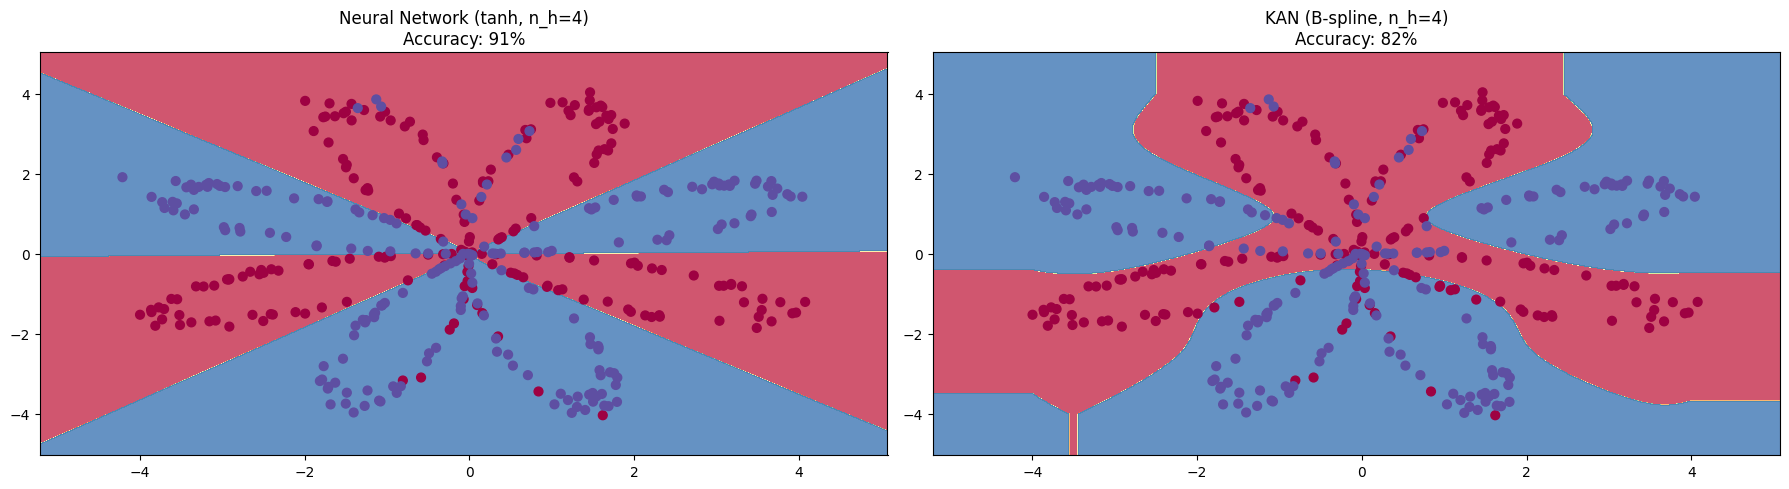

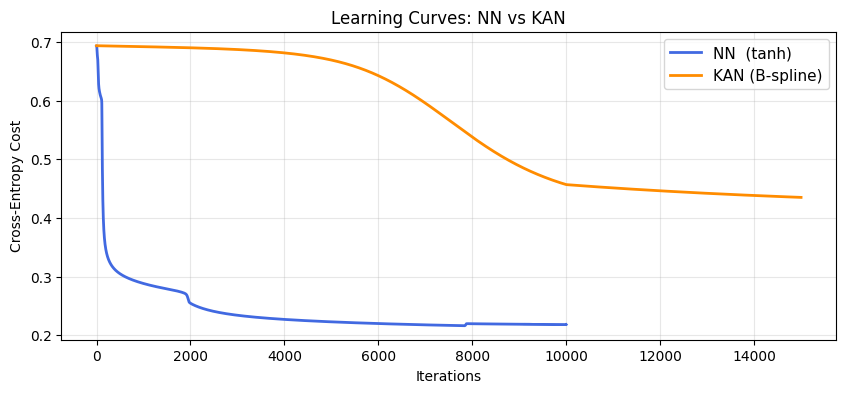

              RESULTS SUMMARY
  Logistic Regression :  47%
  Neural Network (NN) :  91%
  KAN                 :  82%

  Both NN and KAN beat logistic regression by a lot.
  KAN takes more iterations to learn (splines start flat)
  but converges to a competitive boundary.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# plt.sca(axes[0])
# plot_decision_boundary(lambda x: clf.predict(x), X, Y)
# plt.title(f"Logistic Regression\nAccuracy: ~{LR_acc:.0f}%", fontsize=12)

plt.sca(axes[0])
plot_decision_boundary(lambda x: nn_predict(nn_params, x.T), X, Y)
plt.title(f"Neural Network (tanh, n_h=4)\nAccuracy: {nn_acc:.0f}%", fontsize=12)

plt.sca(axes[1])
plot_decision_boundary(lambda x: kan_predict(kan_l1, kan_l2, x.T), X, Y)
plt.title(f"KAN (B-spline, n_h=4)\nAccuracy: {kan_acc:.0f}%", fontsize=12)

plt.tight_layout()
plt.show()

# ── Learning curves ─────────────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(nn_costs,  label='NN  (tanh)', color='royalblue', lw=2)
plt.plot(kan_costs, label='KAN (B-spline)', color='darkorange', lw=2)
plt.xlabel("Iterations")
plt.ylabel("Cross-Entropy Cost")
plt.title("Learning Curves: NN vs KAN")
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print("="*55)
print("              RESULTS SUMMARY")
print("="*55)
print(f"  Logistic Regression :  {LR_acc:.0f}%")
print(f"  Neural Network (NN) :  {nn_acc:.0f}%")
print(f"  KAN                 :  {kan_acc:.0f}%")
print()
print("  Both NN and KAN beat logistic regression by a lot.")
print("  KAN takes more iterations to learn (splines start flat)")
print("  but converges to a competitive boundary.")

<a name='7'></a>
## 7 - Visualize the Learned Functions (KAN's superpower)

This is something you **cannot do** with a standard NN.

In a NN, `W1` is a matrix of numbers — you can't easily interpret what each weight means.

In a KAN, **every edge** has a learned φ function that you can **plot directly**. This is what makes KANs interpretable — you literally see the transformation each connection applies.

/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_3567/2261181803.py:23: RuntimeWarning: divide by zero encountered in matmul
  phi_ij = B[i, :, :] @ layer.coeff[i, j, :] * layer.scale[i, j]
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_3567/2261181803.py:23: RuntimeWarning: overflow encountered in matmul
  phi_ij = B[i, :, :] @ layer.coeff[i, j, :] * layer.scale[i, j]
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_3567/2261181803.py:23: RuntimeWarning: invalid value encountered in matmul
  phi_ij = B[i, :, :] @ layer.coeff[i, j, :] * layer.scale[i, j]


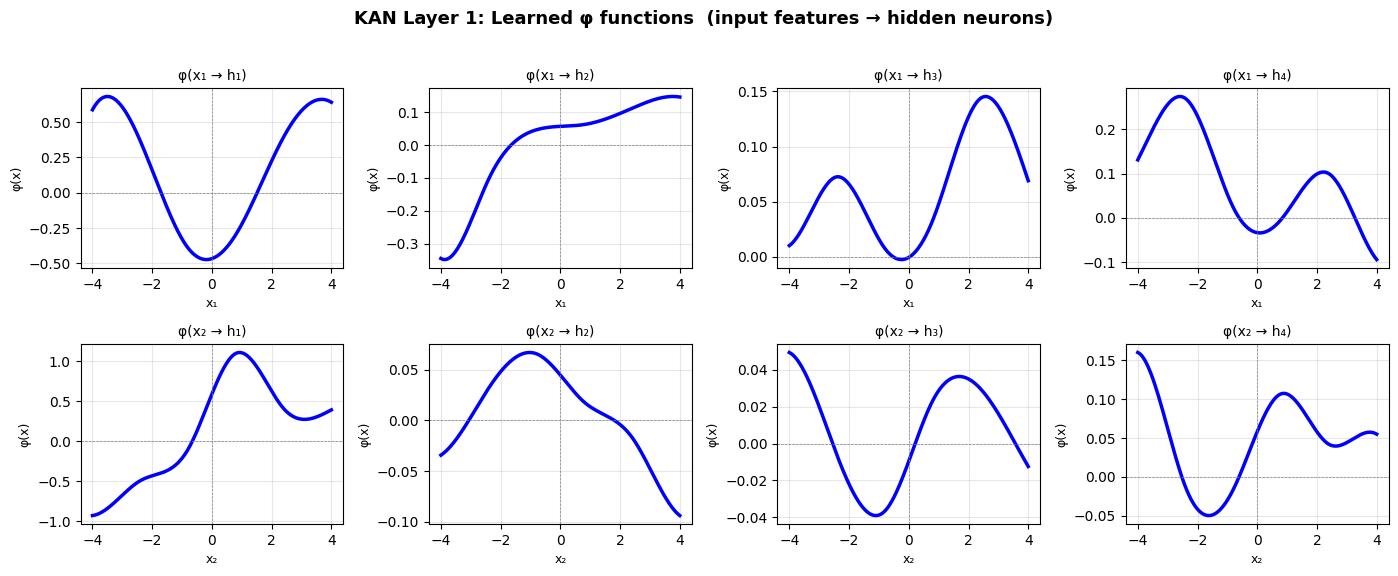

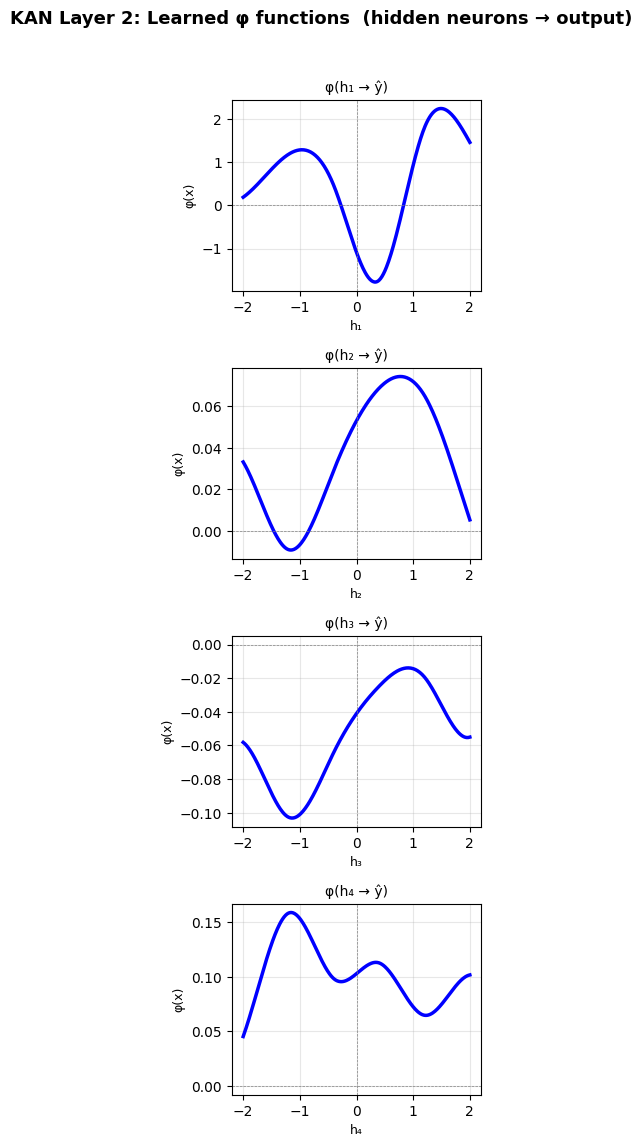

↑ These are the ACTUAL functions your KAN learned from data.
  In your NN, you'd only have a single weight number W[i,j].
  In KAN, you have an entire curve — much richer representation!


In [12]:
def plot_kan_layer_functions(layer, title, input_names, output_names, x_range=(-3.5, 3.5)):
    """
    Plot every learned φᵢⱼ(x) in a KAN layer.
    Each subplot = one edge in the network = one learned curve.
    """
    n_in, n_out = layer.n_in, layer.n_out
    fig, axes = plt.subplots(n_in, n_out, figsize=(3.5 * n_out, 2.8 * n_in))
    if n_in == 1:  axes = axes[np.newaxis, :]
    if n_out == 1: axes = axes[:, np.newaxis]

    x_vals = np.linspace(x_range[0], x_range[1], 300)

    for i in range(n_in):
        # Build dummy input where only dimension i varies
        x_dummy = np.zeros((n_in, 300))
        x_dummy[i] = x_vals

        B, _ = bspline_basis_and_deriv(x_dummy, layer.knots, layer.degree)
        # B shape: (n_in, 300, n_basis)

        for j in range(n_out):
            # φᵢⱼ(x) = B[i, :, :] @ coeff[i, j, :] * scale[i, j]
            phi_ij = B[i, :, :] @ layer.coeff[i, j, :] * layer.scale[i, j]

            ax = axes[i, j]
            ax.plot(x_vals, phi_ij, 'b-', lw=2.5)
            ax.axhline(0, color='gray', lw=0.5, linestyle='--')
            ax.axvline(0, color='gray', lw=0.5, linestyle='--')
            ax.set_title(f'φ({input_names[i]} → {output_names[j]})', fontsize=10)
            ax.set_xlabel(input_names[i], fontsize=9)
            ax.set_ylabel('φ(x)', fontsize=9)
            ax.grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


# Layer 1: 2 inputs × 4 hidden neurons = 8 learned functions
plot_kan_layer_functions(
    kan_l1,
    title="KAN Layer 1: Learned φ functions  (input features → hidden neurons)",
    input_names=['x₁', 'x₂'],
    output_names=['h₁', 'h₂', 'h₃', 'h₄'],
    x_range=(-4, 4)
)

# Layer 2: 4 hidden × 1 output = 4 learned functions
plot_kan_layer_functions(
    kan_l2,
    title="KAN Layer 2: Learned φ functions  (hidden neurons → output)",
    input_names=['h₁', 'h₂', 'h₃', 'h₄'],
    output_names=['ŷ'],
    x_range=(-2, 2)
)

print("↑ These are the ACTUAL functions your KAN learned from data.")
print("  In your NN, you'd only have a single weight number W[i,j].")
print("  In KAN, you have an entire curve — much richer representation!")


── n_h = 1 ──────────────────────
  NN  accuracy: 68%


/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_3567/1262930413.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  acc = float((np.dot(Y, preds.T) + np.dot(1 - Y, 1 - preds.T)) / float(Y.size) * 100)
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_3567/1262930413.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  acc = float((np.dot(Y, preds.T) + np.dot(1 - Y, 1 - preds.T)) / float(Y.size) * 100)


  KAN accuracy: 50%

── n_h = 2 ──────────────────────
  NN  accuracy: 67%
  KAN accuracy: 64%

── n_h = 4 ──────────────────────


/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_3567/869654965.py:16: RuntimeWarning: divide by zero encountered in matmul
  Z2 = W2 @ A1 + b2
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_3567/869654965.py:16: RuntimeWarning: overflow encountered in matmul
  Z2 = W2 @ A1 + b2
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_3567/869654965.py:16: RuntimeWarning: invalid value encountered in matmul
  Z2 = W2 @ A1 + b2


  NN  accuracy: 91%
  KAN accuracy: 82%

── n_h = 8 ──────────────────────


/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_3567/869654965.py:14: RuntimeWarning: divide by zero encountered in matmul
  Z1 = W1 @ X + b1
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_3567/869654965.py:14: RuntimeWarning: overflow encountered in matmul
  Z1 = W1 @ X + b1
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_3567/869654965.py:14: RuntimeWarning: invalid value encountered in matmul
  Z1 = W1 @ X + b1
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_3567/869654965.py:30: RuntimeWarning: divide by zero encountered in matmul
  dW2 = (1/m) * dZ2 @ A1.T
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_3567/869654965.py:30: RuntimeWarning: overflow encountered in matmul
  dW2 = (1/m) * dZ2 @ A1.T
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_3567/869654965.py:30: RuntimeWarning: invalid value encountered in matmul
  dW2 = (1/m) * dZ2 @ A1.T
/var/folders/01/wngn392s07q3mh_nvllkf8pm0000gn/T/ipykernel_3567/86965496

  NN  accuracy: 91%
  KAN accuracy: 76%

── n_h = 16 ──────────────────────
  NN  accuracy: 91%
  KAN accuracy: 72%


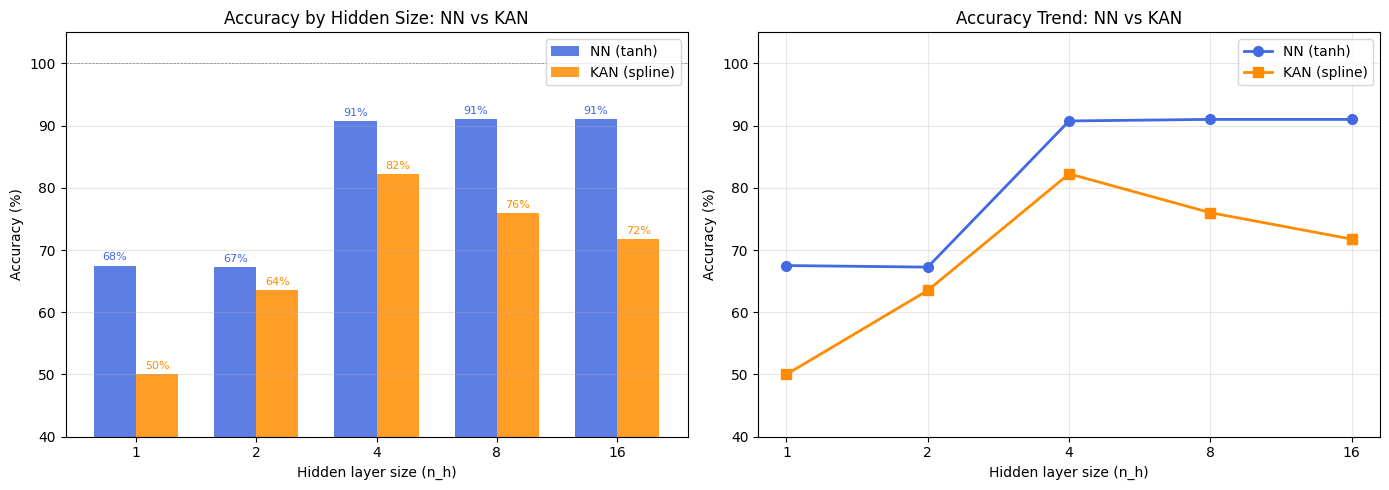


n_h              NN        KAN     Winner
1               68%        50%         NN
2               67%        64%         NN
4               91%        82%         NN
8               91%        76%         NN
16              91%        72%         NN


In [13]:
# ── Compare NN vs KAN across hidden layer sizes ─────────────────────────────

hidden_sizes = (1, 2, 4, 8, 16)

nn_accuracies  = []
kan_accuracies = []

for n_h in hidden_sizes:
    print(f"\n── n_h = {n_h} ──────────────────────")

    # NN
    params, _ = nn_model(X, Y, n_h=n_h, num_iterations=10000, print_cost=False)
    preds = nn_predict(params, X)
    acc = float((np.dot(Y, preds.T) + np.dot(1 - Y, 1 - preds.T)) / float(Y.size) * 100)
    nn_accuracies.append(acc)
    print(f"  NN  accuracy: {acc:.0f}%")

    # KAN
    l1, l2, _ = kan_model(X, Y, n_h=n_h, G=5, num_iterations=15000, lr=2.0, print_cost=False)
    preds = kan_predict(l1, l2, X)
    acc = float((np.dot(Y, preds.T) + np.dot(1 - Y, 1 - preds.T)) / float(Y.size) * 100)
    kan_accuracies.append(acc)
    print(f"  KAN accuracy: {acc:.0f}%")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_pos = range(len(hidden_sizes))
width = 0.35

# Bar chart
axes[0].bar([p - width/2 for p in x_pos], nn_accuracies,  width, label='NN (tanh)',    color='royalblue',  alpha=0.85)
axes[0].bar([p + width/2 for p in x_pos], kan_accuracies, width, label='KAN (spline)', color='darkorange', alpha=0.85)
axes[0].set_xticks(list(x_pos))
axes[0].set_xticklabels([str(n) for n in hidden_sizes])
axes[0].set_xlabel("Hidden layer size (n_h)")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Accuracy by Hidden Size: NN vs KAN")
axes[0].set_ylim(40, 105)
axes[0].axhline(100, color='gray', lw=0.5, linestyle='--')
axes[0].legend()
axes[0].grid(True, axis='y', alpha=0.3)
for i, (nn_a, kan_a) in enumerate(zip(nn_accuracies, kan_accuracies)):
    axes[0].text(i - width/2, nn_a  + 0.5, f"{nn_a:.0f}%",  ha='center', va='bottom', fontsize=8, color='royalblue')
    axes[0].text(i + width/2, kan_a + 0.5, f"{kan_a:.0f}%", ha='center', va='bottom', fontsize=8, color='darkorange')

# Line chart (easier to see trends)
axes[1].plot(hidden_sizes, nn_accuracies,  'o-', label='NN (tanh)',    color='royalblue',  lw=2, markersize=7)
axes[1].plot(hidden_sizes, kan_accuracies, 's-', label='KAN (spline)', color='darkorange', lw=2, markersize=7)
axes[1].set_xlabel("Hidden layer size (n_h)")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy Trend: NN vs KAN")
axes[1].set_ylim(40, 105)
axes[1].set_xscale('log', base=2)
axes[1].set_xticks(hidden_sizes)
axes[1].set_xticklabels([str(n) for n in hidden_sizes])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "="*40)
print(f"{'n_h':<8} {'NN':>10} {'KAN':>10} {'Winner':>10}")
print("="*40)
for n_h, nn_a, kan_a in zip(hidden_sizes, nn_accuracies, kan_accuracies):
    winner = "NN" if nn_a > kan_a else ("KAN" if kan_a > nn_a else "tie")
    print(f"{n_h:<8} {nn_a:>9.0f}% {kan_a:>9.0f}% {winner:>10}")
print("="*40)

## Summary: What You Learned

```
                 NEURAL NETWORK                 KAN
               ──────────────────    ────────────────────────────
Fixed things:  activation (tanh)    node operation (sum)
Learned things: W, b matrices        spline coefficients cₖ
Nonlinearity:  on nodes              on edges
Interpretable: ✗  (W is opaque)     ✓  (plot every φ)
Parameters:    ~12 (for n_h=4)       ~72 (more expressive)
Convergence:   fast (~10k iters)     slower (~15k+ iters)
Good for:      large data, vision    math functions, science
```

### Key takeaways:

1. **Both work** — NN and KAN both beat logistic regression on this non-linear dataset
2. **Same training loop** — forward → cost → backward → update, with the same cross-entropy loss
3. **Different representation** — NN learns *how much* to weight features; KAN learns *how to transform* each feature
4. **KAN is interpretable** — you can plot every learned φ and understand what each connection does
5. **KAN needs more iterations** — spline coefficients start near-zero and need time to develop distinct shapes
6. **KAN is brand new** — proposed by Liu et al. in April 2024; still an active research area

### Where KANs shine:
- Discovering symbolic mathematical formulas from data (e.g., physics equations)
- Scientific problems where interpretability matters
- Problems with known smooth structure

### Where NNs still win:
- Large-scale image/text/audio tasks (LLMs, vision models)
- Speed of training — NNs converge faster
- Mature ecosystem (PyTorch, TensorFlow)

---

> **Reference**: Liu, Z., et al. "KAN: Kolmogorov-Arnold Networks." arXiv:2404.19756 (2024)  
> **pykan library**: https://github.com/KindXiaoming/pykan (official implementation with PyTorch)